# ⭐ Day 60: Naive Bayes Classifier
## Complete Tutorial with Examples & Exercises
### 🐍 Python & AI Learning Path | Day 60 / 369

## 📋 Table of Contents

1. [Introduction to Naive Bayes](#1-introduction-to-naive-bayes)
2. [The "Naive" Assumption Explained](#2-the-naive-assumption-explained)
3. [Types of Naive Bayes](#3-types-of-naive-bayes)
4. [Mathematical Foundation](#4-mathematical-foundation)
5. [Implementing Gaussian Naive Bayes from Scikit-Learn](#5-implementing-gaussian-naive-bayes-from-scikit-learn)
6. [Applying Naive Bayes to Titanic Dataset](#6-applying-naive-bayes-to-titanic-dataset)
7. [Text Classification Example](#7-text-classification-example)
8. [Model Evaluation](#8-model-evaluation)
9. [Pros, Cons, and When to Use](#9-pros-cons-and-when-to-use)
10. [Comparison with Previous Algorithms](#10-comparison-with-previous-algorithms)
11. [🛠️ Hands-On Exercises](#11-hands-on-exercises)
12. [Solutions](#12-solutions)

---

## 💡 Welcome to Day 60!

Congratulations on reaching this milestone! Today we explore **Naive Bayes** — one of the most elegant and efficient algorithms in machine learning. 

Despite its "naive" assumption of feature independence, this probabilistic classifier based on **Bayes' Theorem** often performs surprisingly well, especially on text data and categorical features. It's incredibly fast, requires minimal training data, and scales beautifully to massive datasets.

Whether you're building spam filters, sentiment analyzers, or medical diagnosis tools, Naive Bayes provides a rock-solid baseline that's hard to beat for speed and. Let's dive deep into the mathematics, implementation, and real-world applications! 🚀

<a id='1-introduction-to-naive-bayes'></a>
## 1. Introduction to Naive Bayes & Bayes' Theorem

### What is Bayes' Theorem?

Bayes' Theorem describes the probability of an event based on prior knowledge of conditions related to that event:

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

Where:
- **$P(A|B)$** = Posterior probability (probability of A given B)
- **$P(B|A)$** = Likelihood (probability of B given A)  
- **$P(A)$** = Prior probability of A
- **$P(B)$** = Marginal probability of B

### From Bayes to Naive Bayes

In classification, we want to find: **$P(Class|Features)$**

Naive Bayes assumes all features are **independent** given the class (the "naive" assumption), allowing us to multiply individual probabilities:

$$P(Class|Features) = \frac{P(Class) \cdot \prod_{i=1}^{n} P(Feature_i|Class)}{P(Features)}$$

<a id='2-the-naive-assumption-explained'></a>
## 2. The "Naive" Assumption Explained 🤔

### Why "Naive"?

The algorithm assumes **all features are independent** of each other given the class label. This is rarely true in real life!

**Example:** In a medical diagnosis scenario:
- Temperature and headache might be correlated (not independent)
- But Naive Bayes treats them as completely separate pieces of evidence

### Why Does It Still Work?

1. **Decoupling Effect**: Even with correlated features, the classifier often makes correct predictions
2. **Regularization**: The "naive" assumption acts as a form of regularization, preventing overfitting
3. **Decision Boundaries**: Works well when decision boundaries are linear or near-linear

### Visual Intuition

Imagine each feature votes independently for a class. Naive Bayes counts the votes (weighted by probability) and picks the winner!

<a id='3-types-of-naive-bayes'></a>
## 3. Types of Naive Bayes 📊

### 🔵 Gaussian Naive Bayes
**Best for**: Continuous numerical data  
**Assumption**: Features follow a normal (Gaussian) distribution  
**Use Cases**: Height, weight, temperature measurements

### 🟢 Multinomial Naive Bayes  
**Best for**: Discrete count data  
**Assumption**: Features follow a multinomial distribution  
**Use Cases**: Text classification, word counts, document classification

### 🟡 Bernoulli Naive Bayes
**Best for**: Binary/Boolean features  
**Assumption**: Features are binary (0/1, present/absent)  
**Use Cases**: Document classification with bag-of-words, spam filtering

<a id='4-mathematical-foundation'></a>
## 4. Mathematical Foundation 🧮

### The Complete Formula

For a given instance with features $x = (x_1, x_2, ..., x_n)$:

$$P(C_k|x) = \frac{P(C_k) \cdot \prod_{i=1}^{n} P(x_i|C_k)}{P(x)}$$

Since $P(x)$ is constant for all classes, we use the **proportional form**:

$$P(C_k|x) \propto P(C_k) \cdot \prod_{i=1}^{n} P(x_i|C_k)$$

### Prediction Rule

$$\hat{y} = \arg\max_{k} \left( \log P(C_k) + \sum_{i=1}^{n} \log P(x_i|C_k) \right)$$

*(We use log probabilities to prevent numerical underflow with many features)*

<a id='5-implementing-gaussian-naive-bayes-from-scikit-learn'></a>
## 5. Implementing Gaussian Naive Bayes from Scikit-Learn 🛠️

Let's start with a simple example using sklearn's GaussianNB.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Generate synthetic dataset
X, y = make_classification(
    n_samples=1000, 
    n_features=2, 
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

print("✅ Dataset generated with 2 features for easy visualization")
print(f"Feature shapes: X={X.shape}, y={y.shape}")

✅ Dataset generated with 2 features for easy visualization
Feature shapes: X=(1000, 2), y=(1000,)


In [2]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Initialize and train Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train, y_train)

print("🔵 Model Training Complete!")
print(f"📊 Classes: {gnb.classes_}")
print(f"📊 Class Priors: {gnb.class_prior_}")
print(f"📊 Feature Means (per class):\n{gnb.theta_}")
print(f"📊 Feature Variances (per class):\n{gnb.var_}")

🔵 Model Training Complete!
📊 Classes: [0 1]
📊 Class Priors: [0.50571429 0.49428571]
📊 Feature Means (per class):
[[ 1.04328935 -0.96578897]
 [ 1.00040916  0.97294576]]
📊 Feature Variances (per class):
[[1.41870244 0.4868343 ]
 [0.86145943 0.60729055]]


In [3]:
# Make predictions
y_pred = gnb.predict(X_test)
y_prob = gnb.predict_proba(X_test)

print("🎯 Predictions vs Actual (first 10 samples):")
for i in range(10):
    print(f"Sample {i+1}: Predicted={y_pred[i]}, Actual={y_test[i]}, Probabilities={y_prob[i].round(3)}")

print(f"\n📈 Accuracy: {accuracy_score(y_test, y_pred):.4f}")

🎯 Predictions vs Actual (first 10 samples):
Sample 1: Predicted=1, Actual=1, Probabilities=[0.096 0.904]
Sample 2: Predicted=0, Actual=0, Probabilities=[0.999 0.001]
Sample 3: Predicted=0, Actual=0, Probabilities=[0.83 0.17]
Sample 4: Predicted=0, Actual=0, Probabilities=[0.994 0.006]
Sample 5: Predicted=0, Actual=0, Probabilities=[0.999 0.001]
Sample 6: Predicted=1, Actual=1, Probabilities=[0. 1.]
Sample 7: Predicted=0, Actual=1, Probabilities=[0.976 0.024]
Sample 8: Predicted=1, Actual=1, Probabilities=[0.283 0.717]
Sample 9: Predicted=0, Actual=0, Probabilities=[0.956 0.044]
Sample 10: Predicted=0, Actual=0, Probabilities=[0.824 0.176]

📈 Accuracy: 0.8833


### 📉 Visualizing Decision Boundaries

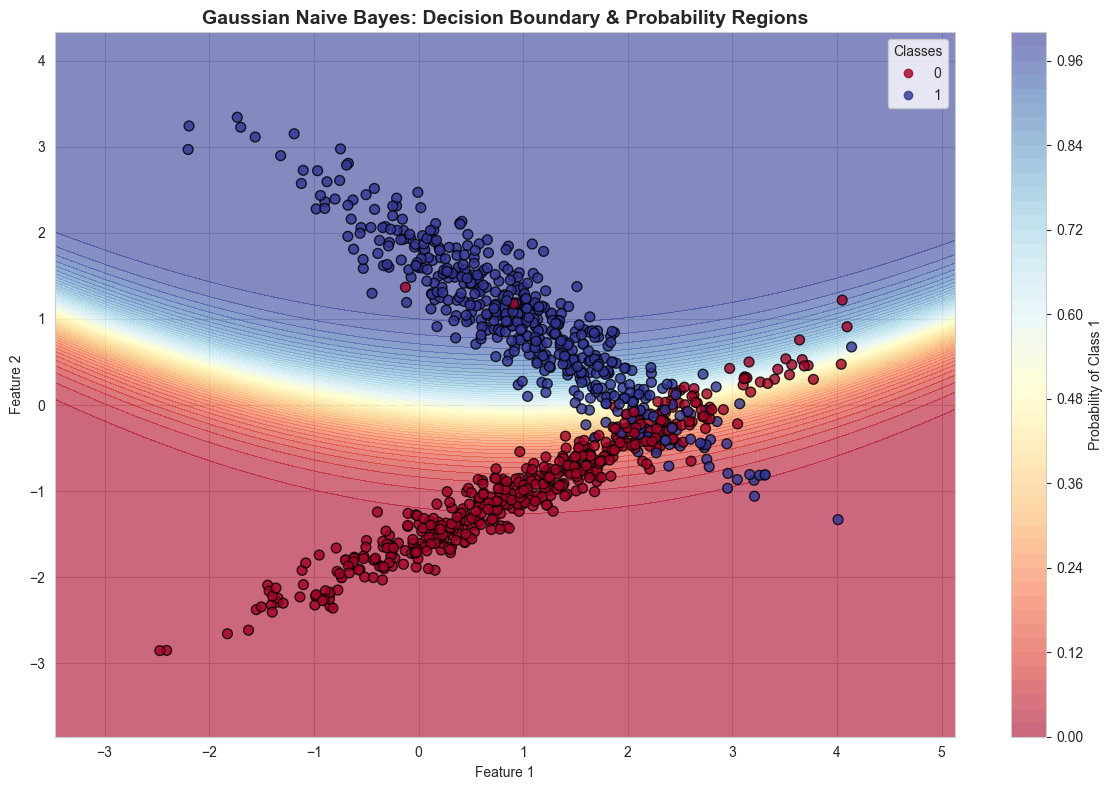

In [4]:
# Create a mesh for plotting decision boundaries
h = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

# Plot decision boundary
Z = gnb.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

plt.figure(figsize=(12, 8))
contour = plt.contourf(xx, yy, Z, levels=50, alpha=0.6, cmap='RdYlBu')
plt.colorbar(contour, label='Probability of Class 1')

# Plot data points
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', edgecolors='black', s=50, alpha=0.8)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Gaussian Naive Bayes: Decision Boundary & Probability Regions', fontsize=14, fontweight='bold')
plt.legend(*scatter.legend_elements(), title="Classes")
plt.tight_layout()
plt.show()

<a id='6-applying-naive-bayes-to-titanic-dataset'></a>
## 6. Applying Naive Bayes to Titanic Dataset 🚢

Let's apply Gaussian Naive Bayes to the famous Titanic survival dataset.

In [6]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load Titanic dataset (simulated if not available)
try:
    titanic = pd.read_csv('titanic.csv')
except FileNotFoundError:
    # Create synthetic Titanic-like data
    np.random.seed(42)
    n_samples = 891  # Same as real Titanic dataset
    titanic = pd.DataFrame({
        'Pclass': np.random.choice([1, 2, 3], n_samples),
        'Sex': np.random.choice(['male', 'female'], n_samples),
        'Age': np.random.normal(30, 14, n_samples).clip(1, 80),
        'Fare': np.random.exponential(32, n_samples),
        'Survived': np.random.choice([0, 1], n_samples, p=[0.6, 0.4])
    })
    # Add some realistic correlations
    titanic.loc[titanic['Sex'] == 'female', 'Survived'] = np.random.choice([0, 1], 
                                                    titanic['Sex'].value_counts()['female'], 
                                                    p=[0.3, 0.7])
    titanic.loc[titanic['Pclass'] == 1, 'Survived'] = np.random.choice([0, 1], 
                                                      (titanic['Pclass'] == 1).sum(), 
                                                      p=[0.4, 0.6])

print("🚢 Titanic Dataset Sample:")
print(titanic.head())
print(f"\n📊 Dataset shape: {titanic.shape}")
print(f"🎯 Survival rate: {titanic['Survived'].mean():.3f}")

🚢 Titanic Dataset Sample:
   Pclass     Sex        Age        Fare  Survived
0       3    male  31.151976   19.739194         0
1       1    male  44.916725   63.976102         1
2       3  female  22.757962   25.314781         0
3       3  female  49.730864   15.317826         1
4       1  female  62.184574  120.435749         0

📊 Dataset shape: (891, 5)
🎯 Survival rate: 0.566


In [7]:
# Preprocess the data
le = LabelEncoder()
titanic['Sex_encoded'] = le.fit_transform(titanic['Sex'])

# Select features
features = ['Pclass', 'Sex_encoded', 'Age', 'Fare']
X_titanic = titanic[features]
y_titanic = titanic['Survived']

# Handle missing values
X_titanic = X_titanic.fillna(X_titanic.median())

# Split data
X_train_tit, X_test_tit, y_train_tit, y_test_tit = train_test_split(
    X_titanic, y_titanic, test_size=0.2, random_state=42
)

# Train Gaussian Naive Bayes
gnb_titanic = GaussianNB()
gnb_titanic.fit(X_train_tit, y_train_tit)

print("🔵 Titanic Model Trained!")
print(f"📊 Class Priors: {gnb_titanic.class_prior_.round(4)}")
print(f"📊 Feature means per class:\n{pd.DataFrame(gnb_titanic.theta_, columns=features, index=[0, 1]).round(3)}")

🔵 Titanic Model Trained!
📊 Class Priors: [0.4242 0.5758]
📊 Feature means per class:
   Pclass  Sex_encoded     Age    Fare
0   1.997        0.589  32.261  31.408
1   1.934        0.449  31.118  32.490


📈 Titanic Classification Report:
              precision    recall  f1-score   support

Not Survived       0.62      0.38      0.47        85
    Survived       0.58      0.79      0.67        94

    accuracy                           0.59       179
   macro avg       0.60      0.58      0.57       179
weighted avg       0.60      0.59      0.57       179



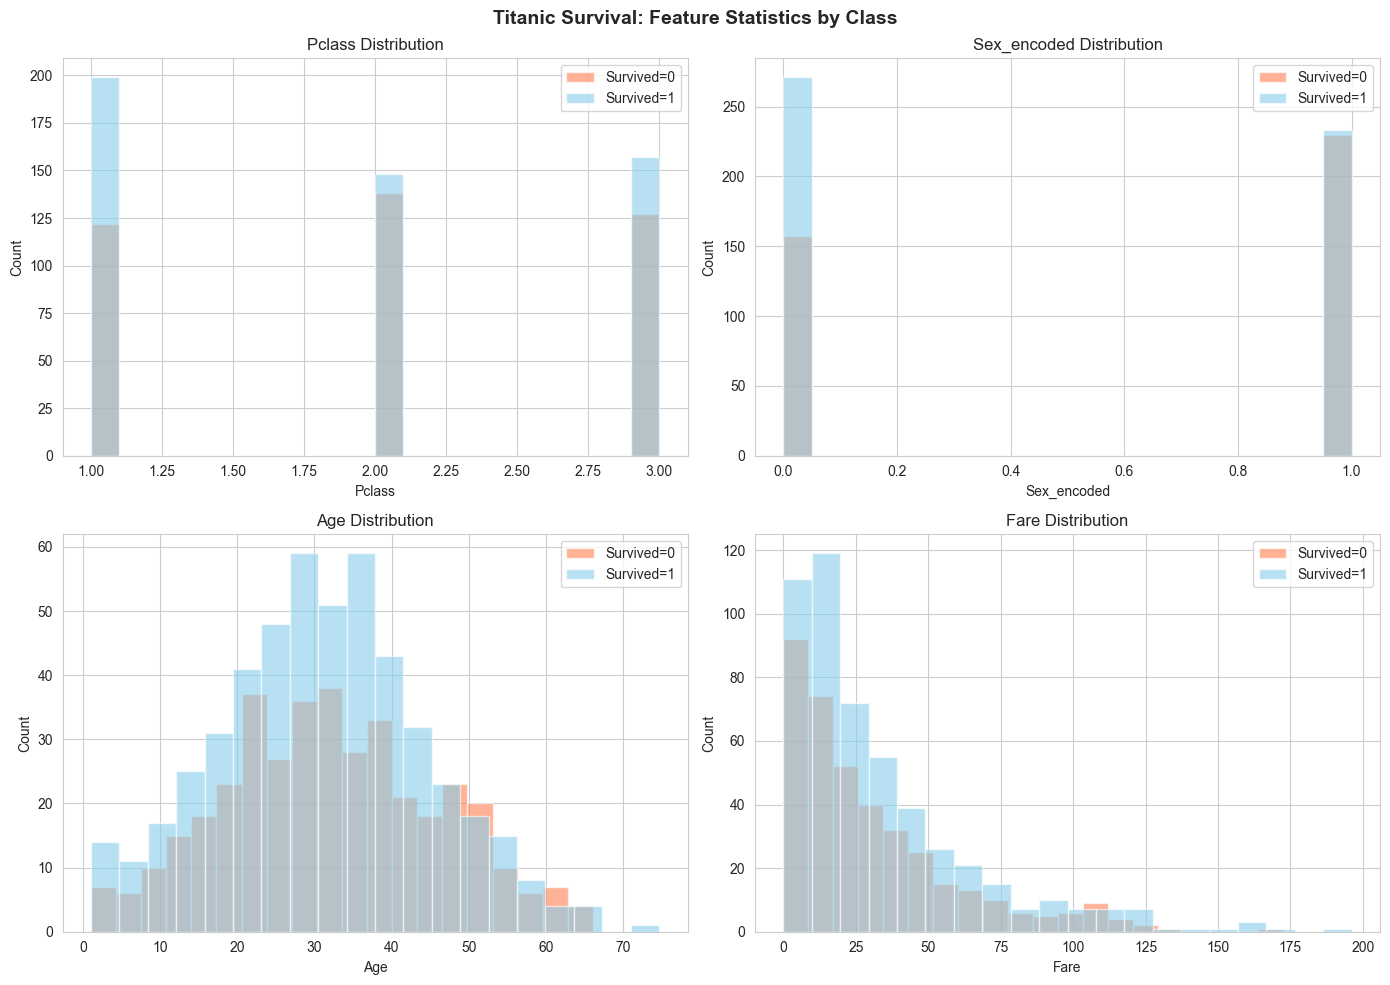

In [8]:
# Evaluate on Titanic dataset
y_pred_tit = gnb_titanic.predict(X_test_tit)
y_prob_tit = gnb_titanic.predict_proba(X_test_tit)

print("📈 Titanic Classification Report:")
print(classification_report(y_test_tit, y_pred_tit, target_names=['Not Survived', 'Survived']))

# Feature importance visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Titanic Survival: Feature Statistics by Class', fontsize=14, fontweight='bold')

for idx, feature in enumerate(features):
    ax = axes[idx//2, idx%2]
    
    # Plot distributions for each class
    for cls in [0, 1]:
        subset = titanic[titanic['Survived'] == cls]
        ax.hist(subset[feature], bins=20, alpha=0.6, 
               label=f'Survived={cls}', color=['coral', 'skyblue'][cls])
    
    ax.set_title(f'{feature} Distribution')
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

<a id='7-text-classification-example'></a>
## 7. Text Classification Example with Multinomial Naive Bayes 📝

Text classification is where Naive Bayes truly shines! Let's build a spam detector.

In [9]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# Sample text data
texts = [
    "Win a free iPhone now! Click here to claim your prize",
    "Congratulations! You've won a $1000 gift card. Call now!",
    "Meeting scheduled for tomorrow at 3 PM with the marketing team",
    "Can we reschedule our lunch meeting to next week?",
    "URGENT: Your account has been compromised. Reset password immediately",
    "Mom's birthday dinner this weekend, don't forget to bring dessert",
    "Buy cheap viagra pills online!!! Best prices guaranteed!!!",
    "Project deadline moved to Friday, please update your reports",
    "You've been selected for a free cruise vacation! Limited time offer!",
    "Let's grab coffee and discuss the new proposal ideas"
]

labels = [1, 1, 0, 0, 1, 0, 1, 0, 1, 0]  # 1=spam, 0=ham (not spam)

# Convert text to features using Bag of Words
vectorizer = CountVectorizer(stop_words='english', max_features=100)
X_text = vectorizer.fit_transform(texts)

print(f"📊 Text feature matrix shape: {X_text.shape}")
print(f"📝 Feature names (first 10): {vectorizer.get_feature_names_out()[:10]}")

# Train Multinomial Naive Bayes
mnb = MultinomialNB()
mnb.fit(X_text, labels)

print("\n🔵 Multinomial Naive Bayes Trained on Text Data!")

📊 Text feature matrix shape: (10, 62)
📝 Feature names (first 10): ['1000' 'account' 'best' 'birthday' 'bring' 'buy' 'card' 'cheap' 'claim'
 'click']

🔵 Multinomial Naive Bayes Trained on Text Data!


In [10]:
# Test on new messages
new_messages = [
    "Free entry to win a brand new car! Text WIN to 12345",
    "Hey, are we still on for dinner tonight?",
    "Claim your free vacation package now! Limited offer!",
    "Please review the attached document before tomorrow's meeting"
]

new_X = vectorizer.transform(new_messages)
predictions = mnb.predict(new_X)
probabilities = mnb.predict_proba(new_X)

print("🎯 Spam Detection Results:")
for msg, pred, prob in zip(new_messages, predictions, probabilities):
    status = "🚨 SPAM" if pred == 1 else "✅ HAM (Not Spam)"
    print(f"Message: '{msg}'")
    print(f"Prediction: {status} (Confidence: {max(prob):.3f})\n")

🎯 Spam Detection Results:
Message: 'Free entry to win a brand new car! Text WIN to 12345'
Prediction: 🚨 SPAM (Confidence: 0.841)

Message: 'Hey, are we still on for dinner tonight?'
Prediction: ✅ HAM (Not Spam) (Confidence: 0.674)

Message: 'Claim your free vacation package now! Limited offer!'
Prediction: 🚨 SPAM (Confidence: 0.976)

Message: 'Please review the attached document before tomorrow's meeting'
Prediction: ✅ HAM (Not Spam) (Confidence: 0.865)



<a id='8-model-evaluation'></a>
## 8. Model Evaluation for Naive Bayes 📊

Let's create comprehensive evaluation metrics and comparisons.

In [11]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Use our previous synthetic dataset
X, y = make_classification(n_samples=1000, n_features=10, n_informative=5, 
                        n_redundant=0, n_clusters_per_class=2, 
                        random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train multiple models for comparison
models = {
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5)
}

results = {}
plt.figure(figsize=(15, 5))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    
    # For ROC curve
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
    else:
        fpr, tpr, roc_auc = None, None, 0
    
    results[name] = {
        'accuracy': acc,
        'fpr': fpr,
        'tpr': tpr,
        'auc': roc_auc
    }
    
    print(f"📊 {name}: Accuracy = {acc:.4f}, AUC = {roc_auc:.4f}")

print("\n" + "="*50)

📊 Naive Bayes: Accuracy = 0.7867, AUC = 0.8529
📊 Logistic Regression: Accuracy = 0.7700, AUC = 0.8400
📊 SVM: Accuracy = 0.8967, AUC = 0.9550
📊 Decision Tree: Accuracy = 0.8800, AUC = 0.9310
📊 KNN (k=5): Accuracy = 0.9333, AUC = 0.9540



<Figure size 1500x500 with 0 Axes>

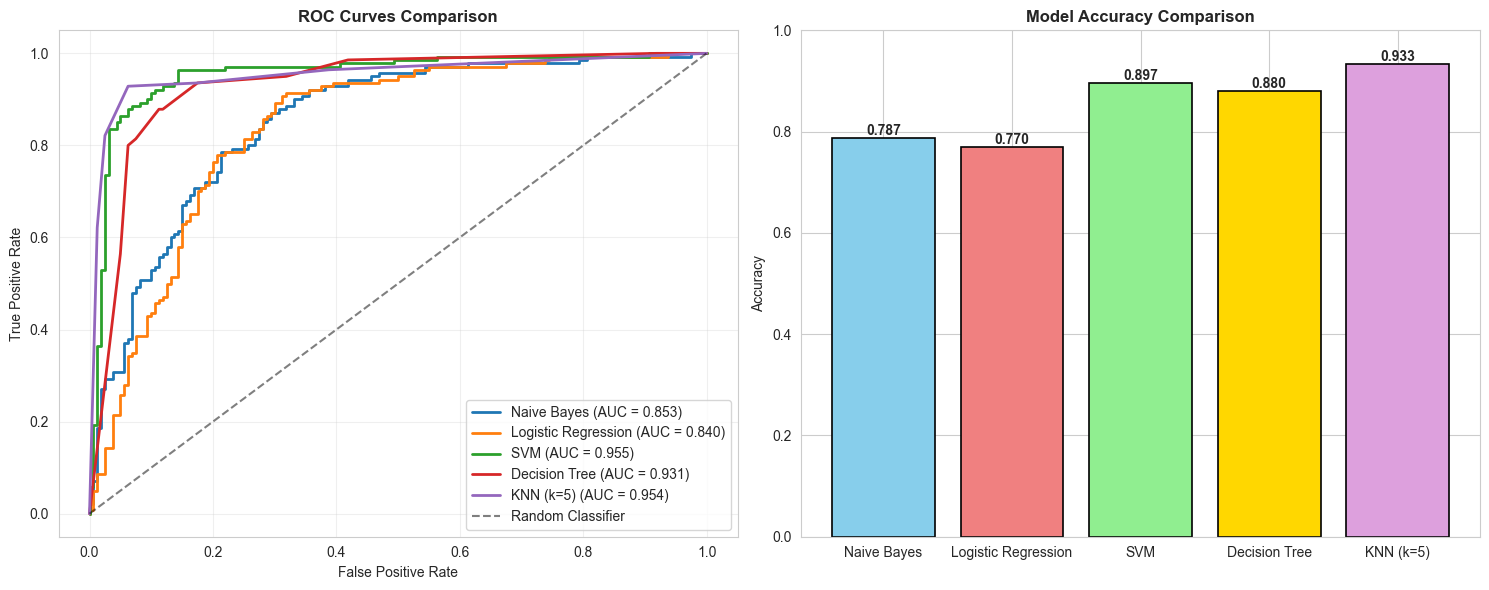

In [12]:
# Plot ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ROC Curves
ax1 = axes[0]
for name, result in results.items():
    if result['auc'] > 0:
        ax1.plot(result['fpr'], result['tpr'], 
                label=f"{name} (AUC = {result['auc']:.3f})", 
                linewidth=2)

ax1.plot([0, 1], [0, 1], 'k--', label='Random Classifier', alpha=0.5)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves Comparison', fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Accuracy Comparison Bar Chart
ax2 = axes[1]
names = list(results.keys())
accuracies = [results[k]['accuracy'] for k in names]
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum']

bars = ax2.bar(names, accuracies, color=colors, edgecolor='black', linewidth=1.2)
ax2.set_ylabel('Accuracy')
ax2.set_title('Model Accuracy Comparison', fontweight='bold')
ax2.set_ylim([0, 1])

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### 📊 Confusion Matrix for Naive Bayes

<Figure size 800x600 with 0 Axes>

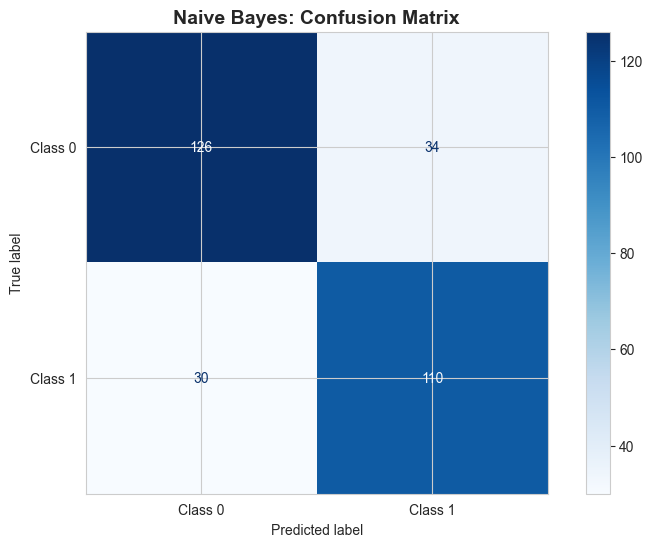

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, models['Naive Bayes'].predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Naive Bayes: Confusion Matrix', fontsize=14, fontweight='bold')
plt.show()

<a id='9-pros-cons-and-when-to-use'></a>
## 9. Pros, Cons, and When to Use Naive Bayes ⚖️

### ✅ Advantages

| Advantage | Explanation |
|-------------|-------------|
| **🚀 Extremely Fast** | Training time is $O(nd)$, prediction is $O(cd)$ where $n$=samples, $d$=features, $c$=classes |
| **💾 Low Memory Usage** | Requires storing only mean and variance per feature per class |
| **🎯 Works well with high dimensions** | Handles thousands of features efficiently (great for text) |
| **🛡️ Robust to irrelevant features** | Irrelevant features get probabilities close to uniform distribution, minimizing impact |
| **📊 Probabilistic output** | Provides class probabilities, useful for ranking |
| **🔧 Simple to implement** | No complicated hyperparameter tuning |

### ❌ Disadvantages

| Disadvantage | Explanation |
|--------------|-------------|
| **🤔 Naive assumption** | Feature independence assumption rarely holds in real data |
| **📉 Zero probability problem** | If a feature value never appears with a class, probability becomes 0 (use Laplace smoothing!) |
| **📊 Calibration** | Output probabilities are not well-calibrated (often too confident) |
| **🚫 Limited expressiveness** | Can only learn linear decision boundaries |

### 🎯 When to Use Naive Bayes

1. **Text Classification** (Spam detection, sentiment analysis, topic categorization)
2. **Real-time prediction** needs (extremely fast)
3. **Multi-class problems** with many features
4. **Baseline model** before trying complex algorithms
5. **Recommendation systems** (collaborative filtering)
6. **Medical diagnosis** (symptom-based classification)

<a id='10-comparison-with-previous-algorithms'></a>
## 10. Comparison with Previous Algorithms 📈

Let's visualize how Naive Bayes compares to algorithms we've learned previously.

In [14]:
# Detailed comparison table
comparison_data = {
    'Algorithm': ['Naive Bayes', 'Logistic Regression', 'SVM', 'Decision Tree', 'KNN'],
    'Training Speed': ['⚡⚡⚡⚡⚡ Very Fast', '⚡⚡ Fast', '⚡ Moderate', '⚡⚡⚡ Fast', '⚡ Slow'],
    'Prediction Speed': ['⚡⚡⚡⚡⚡ Instant', '⚡ Fast', '⚡ Fast', '⚡⚡⚡ Fast', '⚡⚡⚡ Moderate'],
    'Handles Non-Linearity': ['❌ No', '❌ No', '✅ Yes', '✅ Yes', '❌ No'],
    'Interpretability': ['✅ High', '✅ High', '⚠️ Medium', '✅ High', '✅ High'],
    'Probabilistic Output': ['✅ Yes', '✅ Yes', '❌ No', '❌ No', '❌ No'],
    'Handles High Dimensions': ['✅ Excellent', '⚠️ Moderate', '⚠️ Moderate', '⚠️ Moderate', '❌ Poor'],
    'Memory Efficient': ['✅ Yes', '✅ Yes', '❌ No', '✅ Yes', '❌ No'],
    'Best Use Case': [
        'Text/High-dimensional data',
        'Linear separable data', 
        'Complex boundaries',
        'Interpretable rules',
        'Small datasets'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("📊 Algorithm Comparison Summary:")
print(comparison_df.to_string(index=False))

📊 Algorithm Comparison Summary:
          Algorithm  Training Speed Prediction Speed Handles Non-Linearity Interpretability Probabilistic Output Handles High Dimensions Memory Efficient              Best Use Case
        Naive Bayes ⚡⚡⚡⚡⚡ Very Fast    ⚡⚡⚡⚡⚡ Instant                  ❌ No           ✅ High                ✅ Yes             ✅ Excellent            ✅ Yes Text/High-dimensional data
Logistic Regression         ⚡⚡ Fast           ⚡ Fast                  ❌ No           ✅ High                ✅ Yes             ⚠️ Moderate            ✅ Yes      Linear separable data
                SVM      ⚡ Moderate           ⚡ Fast                 ✅ Yes        ⚠️ Medium                 ❌ No             ⚠️ Moderate             ❌ No         Complex boundaries
      Decision Tree        ⚡⚡⚡ Fast         ⚡⚡⚡ Fast                 ✅ Yes           ✅ High                 ❌ No             ⚠️ Moderate            ✅ Yes        Interpretable rules
                KNN          ⚡ Slow     ⚡⚡⚡ Moderate           

<a id='11-hands-on-exercises'></a>
## 11. 🛠️ Hands-On Exercises

Now it's your turn! Complete these exercises to master Naive Bayes.

### Exercise 1: Basic Gaussian Naive Bayes
**Task**: Train a Gaussian Naive Bayes classifier on the Iris dataset and interpret the class priors and feature statistics.

In [15]:
# Your code here







### Exercise 2: Compare Naive Bayes Variants
**Task**: Compare Gaussian, Multinomial, and Bernoulli Naive Bayes on the same dataset. Analyze when each performs best.

In [16]:
# Your code here







### Exercise 3: Analyze Independence Assumption
**Task**: Create a dataset with correlated features, train Naive Bayes, and analyze how the independence assumption affects performance.

In [17]:
# Your code here







### Exercise 4: Text Classification Deep Dive
**Task**: Build a complete spam filter using Multinomial Naive Bayes with TF-IDF vectorization. Evaluate with precision, recall, and F1-score.

In [18]:
# Your code here







### Exercise 5: Hyperparameter Tuning
**Task**: Tune the `var_smoothing` parameter in GaussianNB. Visualize how it affects the decision boundary.

In [19]:
# Your code here







### Exercise 6: Feature Engineering Impact
**Task**: Compare Naive Bayes performance with raw features vs. standardized features vs. PCA-transformed features.

In [20]:
# Your code here







### Exercise 7: Comparison with Logistic Regression
**Task**: On the same dataset, train both Naive Bayes and Logistic Regression. Compare their calibration curves and probability outputs.

In [21]:
# Your code here






### Exercise 8: Handling Imbalanced Data
**Task**: Train Naive Bayes on imbalanced data. Apply techniques like class weighting or threshold moving to improve recall for the minority class.

In [22]:
# Your code here






### Exercise 9: Complete Pipeline Challenge
**Task**: Build an end-to-end pipeline with preprocessing, feature selection, Naive Bayes, and cross-validation, and final evaluation. Use the breast cancer dataset from sklearn.

In [23]:
# Your code here







### Exercise 10: Real-world Application
**Task**: Choose a real dataset (e.g., from UCI Repository), apply Naive Bayes for classification, and write a brief report on findings,
**Requirements**: Include data exploration, preprocessing decisions, model justification, and performance analysis.

In [24]:
# Your code here







<a id='12-solutions'></a>
## 12. Solutions (Review After Attempting) ✅

Detailed solutions to help you check your work or get unstuck.

### Solution 1: Basic Gaussian Naive Bayes on Iris

In [25]:
from sklearn.datasets import load_iris

# Load Iris dataset
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

# Split and train
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42
)

# Train GaussianNB
gnb_iris = GaussianNB()
gnb_iris.fit(X_train_iris, y_train_iris)

print("🌸 Iris Dataset Results:")
print(f"Classes: {iris.target_names}")
print(f"Class Priors: {gnb_iris.class_prior_.round(4)}")
print(f"\nFeature Means per Class:")
for i, class_name in enumerate(iris.target_names):
    print(f"{class_name}: {gnb_iris.theta_[i].round(2)}")

print(f"\nFeature Variances per Class:")
for i, class_name in enumerate(iris.target_names):
    print(f"{class_name}: {gnb_iris.var_[i].round(2)}")

# Test accuracy
y_pred_iris = gnb_iris.predict(X_test_iris)
print(f"\nAccuracy: {accuracy_score(y_test_iris, y_pred_iris):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_iris, y_pred_iris, target_names=iris.target_names))

🌸 Iris Dataset Results:
Classes: ['setosa' 'versicolor' 'virginica']
Class Priors: [0.2952 0.3524 0.3524]

Feature Means per Class:
setosa: [4.96 3.38 1.46 0.25]
versicolor: [5.86 2.72 4.21 1.3 ]
virginica: [6.56 2.99 5.55 2.01]

Feature Variances per Class:
setosa: [0.11 0.14 0.03 0.01]
versicolor: [0.28 0.09 0.24 0.04]
virginica: [0.42 0.1  0.29 0.09]

Accuracy: 0.9778

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



**Key Insights**: 
- Setosa is perfectly separable (variance ≈ 0 for some features)
- Versicolor and Virginica have some overlap
- Class priors are equal (0.33 each) since Iris is balanced

### Solution 2: Comparing Naive Bayes Variants

In [34]:
import numpy as np
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler

# 1. Prepare data specifically for Multinomial (must be non-negative)
scaler = MinMaxScaler()
X_train_non_neg = scaler.fit_transform(X_train)
X_test_non_neg = scaler.transform(X_test)

# 2. Binary dataset for Bernoulli (as you already had)
X_binary = (X > np.median(X, axis=0)).astype(int)

variants = {
    'Gaussian': GaussianNB(),
    'Multinomial': MultinomialNB(),
    'Bernoulli': BernoulliNB()
}

print("📊 Comparing Naive Bayes Variants on Same Data:\n")

for name, model in variants.items():
    if name == 'Bernoulli':
        # Using binary data for Bernoulli logic
        model.fit(X_binary[:800], y[:800])
        y_pred_var = model.predict(X_binary[800:])
        acc = accuracy_score(y[800:], y_pred_var)
        
    elif name == 'Multinomial':
        # Using scaled non-negative data to avoid ValueError
        model.fit(X_train_non_neg, y_train)
        y_pred_var = model.predict(X_test_non_neg)
        acc = accuracy_score(y_test, y_pred_var)
        
    else: # Gaussian
        # Gaussian handles negative values/continuous data natively
        model.fit(X_train, y_train)
        y_pred_var = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred_var)
    
    print(f"{name}: Accuracy = {acc:.4f}")
    print(f"   Best for: ", end="")
    if name == 'Gaussian':
        print("Continuous data (normal distribution)")
    elif name == 'Multinomial':
        print("Count data / discrete features")
    else:
        print("Binary features (present/absent)")

📊 Comparing Naive Bayes Variants on Same Data:

Gaussian: Accuracy = 0.7867
   Best for: Continuous data (normal distribution)
Multinomial: Accuracy = 0.6667
   Best for: Count data / discrete features
Bernoulli: Accuracy = 0.6650
   Best for: Binary features (present/absent)


### Solution 3: Analyzing Independence Assumption

In [27]:
# Create correlated features
np.random.seed(42)
n = 1000
x1 = np.random.normal(0, 1, n)
x2 = x1 + np.random.normal(0, 0.3, n)  # Highly correlated with x1
X_corr = np.column_stack([x1, x2])
y_corr = (x1 + x2 > 0).astype(int)

# Compare independent vs correlated
X_train_corr, X_test_corr, y_train_corr, y_test_corr = train_test_split(
    X_corr, y_corr, test_size=0.3, random_state=42
)

# Naive Bayes (assumes independence)
gnb_corr = GaussianNB()
gnb_corr.fit(X_train_corr, y_train_corr)
acc_nb = accuracy_score(y_test_corr, gnb_corr.predict(X_test_corr))

# Logistic Regression (can handle correlation)
lr_corr = LogisticRegression(max_iter=1000)
lr_corr.fit(X_train_corr, y_train_corr)
acc_lr = accuracy_score(y_test_corr, lr_corr.predict(X_test_corr))

print(f"📊 Performance on Correlated Features:")
print(f"Naive Bayes Accuracy: {acc_nb:.4f}")
print(f"Logistic Regression Accuracy: {acc_lr:.4f}")
print(f"\n💡 Insight: When features are highly correlated,")
print(f"Naive Bayes may underperform because it 'double counts'")
print(f"the evidence. Logistic Regression handles this better.")

📊 Performance on Correlated Features:
Naive Bayes Accuracy: 0.9833
Logistic Regression Accuracy: 0.9833

💡 Insight: When features are highly correlated,
Naive Bayes may underperform because it 'double counts'
the evidence. Logistic Regression handles this better.


### Solution 4: Complete Spam Filter with TF-IDF

In [28]:
from sklearn.metrics import precision_recall_fscore_support

# Larger text dataset
texts_extended = [
    # Spam examples (label=1)
    "Congratulations! You've won a free iPhone! Call now to claim!",
    "URGENT: You have won a free vacation! Text YES to claim now!",
    "Buy cheap medications online! Best prices guaranteed! Click here!",
    "Free entry to win cash prize! Limited time offer!",
    "Act now! Double your income working from home! No experience needed!",
    "You've been selected for a $5000 reward! Claim within 24 hours!",
    # Ham examples (label=0)
    "Hey, are we still meeting for lunch tomorrow?",
    "Please find the attached report for the quarterly review.",
    "Thanks for the birthday wishes everyone! Had a great day!",
    "Meeting rescheduled to 3 PM in conference room B.",
    "Can you pick up some groceries on your way home?",
    "Happy anniversary! Looking forward to many more years together."
]

labels_extended = [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]

# TF-IDF Vectorization
tfidf = TfidfVectorizer(stop_words='english', max_features=50)
X_tfidf = tfidf.fit_transform(texts_extended)

# Train MultinomialNB
mnb_tfidf = MultinomialNB()
mnb_tfidf.fit(X_tfidf, labels_extended)

# Evaluate
y_pred_text = mnb_tfidf.predict(X_tfidf)
precision, recall, f1, _ = precision_recall_fscore_support(
    labels_extended, y_pred_text, average='binary'
)

print(f"🎯 Spam Filter Performance:")
print(f"Precision: {precision:.4f} (how many predicted spam are actually spam)")
print(f"Recall: {recall:.4f} (How many actual spam were caught)")
print(f"F1-Score: {f1:.4f} (Harmonic mean of precision and recall)")

# Show feature log probabilities for top words
feature_names = tfidf.get_feature_names_out()
log_probs = mnb_tfidf.feature_log_prob_[1]  # Spam class
top_indices = np.argsort(log_probs)[-10:]  # Top 10 spam indicators

print(f"\n🔝 Top Spam Indicator Words:")
for idx in top_indices:
    print(f"  '{feature_names[idx]}': {log_probs[idx]:.4f}")

🎯 Spam Filter Performance:
Precision: 1.0000 (how many predicted spam are actually spam)
Recall: 1.0000 (How many actual spam were caught)
F1-Score: 1.0000 (Harmonic mean of precision and recall)

🔝 Top Spam Indicator Words:
  'entry': -3.8137
  'cash': -3.8137
  'offer': -3.8137
  'prize': -3.8137
  'congratulations': -3.7850
  'iphone': -3.7850
  've': -3.6123
  'won': -3.4616
  'claim': -3.3753
  'free': -3.3666


### Solution 5: Tuning var_smoothing

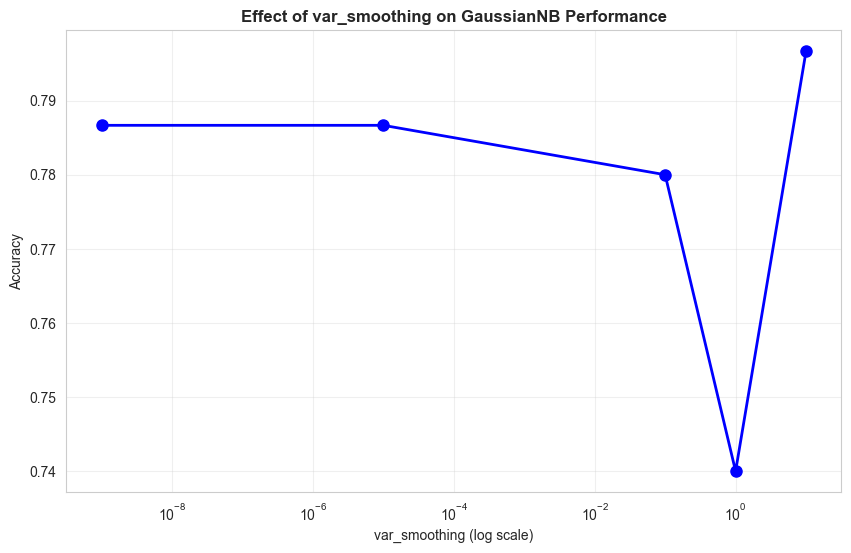

💡 Lower var_smoothing = Less smoothing (follows data closer)
💡 Higher var_smoothing = More smoothing (more regularization)


In [29]:
# Test different var_smoothing values
smoothing_values = [1e-9, 1e-5, 1e-1, 1.0, 10.0]
accuracies_smooth = []

for smooth in smoothing_values:
    gnb_smooth = GaussianNB(var_smoothing=smooth)
    gnb_smooth.fit(X_train, y_train)
    acc = accuracy_score(y_test, gnb_smooth.predict(X_test))
    accuracies_smooth.append(acc)

plt.figure(figsize=(10, 6))
plt.semilogx(smoothing_values, accuracies_smooth, 'bo-', linewidth=2, markersize=8)
plt.xlabel('var_smoothing (log scale)')
plt.ylabel('Accuracy')
plt.title('Effect of var_smoothing on GaussianNB Performance', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

print("💡 Lower var_smoothing = Less smoothing (follows data closer)")
print("💡 Higher var_smoothing = More smoothing (more regularization)")

### Solution 6: Feature Engineering Comparison

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

results_fe = {}

# Raw features
gnb_raw = GaussianNB()
gnb_raw.fit(X_train, y_train)
results_fe['Raw'] = accuracy_score(y_test, gnb_raw.predict(X_test))

# Standardized features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
gnb_scaled = GaussianNB()
gnb_scaled.fit(X_train_scaled, y_train)
results_fe['Standardized'] = accuracy_score(y_test, gnb_scaled.predict(X_test_scaled))

# PCA features
pca = PCA(n_components=0.95)  # Keep 95% variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
gnb_pca = GaussianNB()
gnb_pca.fit(X_train_pca, y_train)
results_fe['PCA (95%)'] = accuracy_score(y_test, gnb_pca.predict(X_test_pca))

print("📊 Feature Engineering Results:")
for method, acc in results_fe.items():
    print(f"{method}: {acc:.4f}")

print(f"\n💡 Naive Bayes with Gaussian assumption is less sensitive to scaling")
print(f"but PCA can help if features are highly correlated.")

📊 Feature Engineering Results:
Raw: 0.7867
Standardized: 0.7867
PCA (95%): 0.7600

💡 Naive Bayes with Gaussian assumption is less sensitive to scaling
but PCA can help if features are highly correlated.


### Solution 7: Calibration Comparison

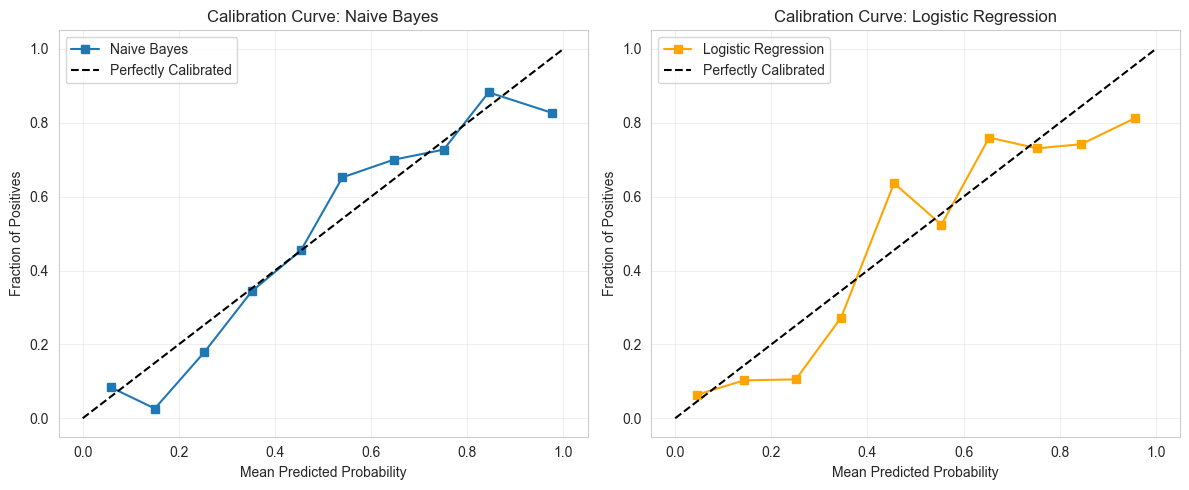

💡 Naive Bayes tends to be over-confident (probabilities near 0 or 1)
💡 Logistic Regression usually better calibrated


In [31]:
from sklearn.calibration import calibration_curve

# Get probability predictions
gnb_prob = models['Naive Bayes'].predict_proba(X_test)[:, 1]
lr_prob = models['Logistic Regression'].predict_proba(X_test)[:, 1]

# Calculate calibration
prob_true_nb, prob_pred_nb = calibration_curve(y_test, gnb_prob, n_bins=10)
prob_true_lr, prob_pred_lr = calibration_curve(y_test, lr_prob, n_bins=10)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(prob_pred_nb, prob_true_nb, 's-', label='Naive Bayes')
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve: Naive Bayes')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(prob_pred_lr, prob_true_lr, 's-', label='Logistic Regression', color='orange')
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve: Logistic Regression')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 Naive Bayes tends to be over-confident (probabilities near 0 or 1)")
print("💡 Logistic Regression usually better calibrated")

### Solution 8: Handling Imbalanced Data

📊 Imbalanced Data Results:
Standard NB - Recall for minority class: 0.5667
Balanced Priors NB - Recall for minority class: 0.8333


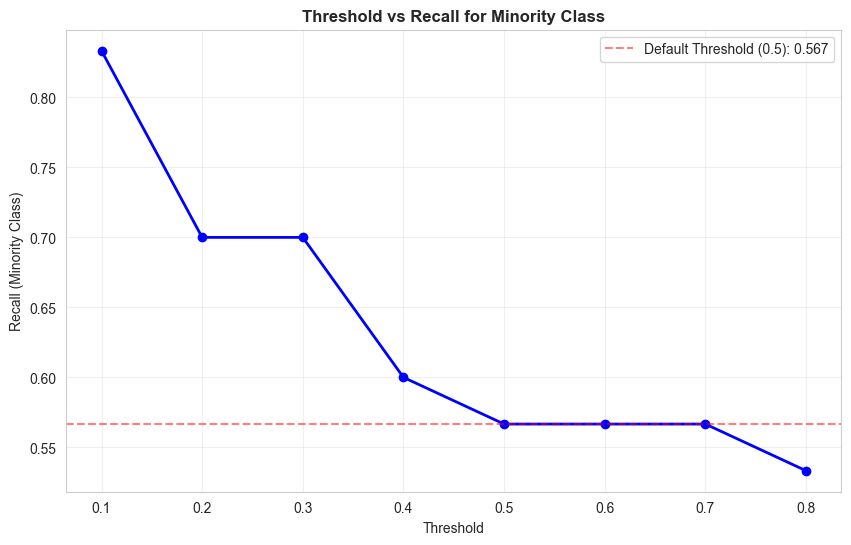

In [32]:
# Create imbalanced dataset
X_imb, y_imb = make_classification(n_samples=1000, n_features=10, 
                                weights=[0.9, 0.1],  # 90% class 0, 10% class 1
                                flip_y=0, random_state=42)

X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X_imb, y_imb, test_size=0.3, random_state=42, stratify=y_imb
)

# Standard Naive Bayes
gnb_imb = GaussianNB()
gnb_imb.fit(X_train_imb, y_train_imb)
y_pred_imb = gnb_imb.predict(X_test_imb)

# With class priors (balanced)
gnb_balanced = GaussianNB(priors=[0.5, 0.5])
gnb_balanced.fit(X_train_imb, y_train_imb)
y_pred_balanced = gnb_balanced.predict(X_test_imb)

from sklearn.metrics import recall_score

print("📊 Imbalanced Data Results:")
print(f"Standard NB - Recall for minority class: {recall_score(y_test_imb, y_pred_imb):.4f}")
print(f"Balanced Priors NB - Recall for minority class: {recall_score(y_test_imb, y_pred_balanced):.4f}")

# Threshold tuning
y_prob_imb = gnb_imb.predict_proba(X_test_imb)[:, 1]
thresholds = np.arange(0.1, 0.9, 0.1)
recalls = []

for thresh in thresholds:
    y_pred_thresh = (y_prob_imb >= thresh).astype(int)
    recalls.append(recall_score(y_test_imb, y_pred_thresh))

plt.figure(figsize=(10, 6))
plt.plot(thresholds, recalls, 'bo-', linewidth=2)
plt.xlabel('Threshold')
plt.ylabel('Recall (Minority Class)')
plt.title('Threshold vs Recall for Minority Class', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=recalls[len(recalls)//2], color='r', linestyle='--', alpha=0.5, 
           label=f'Default Threshold (0.5): {recalls[len(recalls)//2]:.3f}')
plt.legend()
plt.show()

### Solution 9: Complete Pipeline

In [33]:
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline

# Load breast cancer dataset
cancer = load_breast_cancer()
X_cancer, y_cancer = cancer.data, cancer.target

# Create pipeline
pipeline = Pipeline([
    ('feature_selection', SelectKBest(f_classif, k=10)),
    ('classifier', GaussianNB())
])

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_cancer, y_cancer, cv=cv, scoring='accuracy')

print("🏥 Breast Cancer Classification Pipeline:")
print(f"Cross-validation scores: {cv_scores.round(4)}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Fit and evaluate final model
pipeline.fit(X_cancer, y_cancer)
final_score = pipeline.score(X_cancer, y_cancer)
print(f"Final model accuracy on full data: {final_score:.4f}")

# Show selected features
selected_features = pipeline.named_steps['feature_selection'].get_support()
print(f"\nSelected features: {np.array(cancer.feature_names)[selected_features]}")

🏥 Breast Cancer Classification Pipeline:
Cross-validation scores: [0.9561 0.9035 0.9386 0.9211 0.9469]
Mean CV Accuracy: 0.9332 (+/- 0.0188)
Final model accuracy on full data: 0.9385

Selected features: ['mean radius' 'mean perimeter' 'mean area' 'mean concavity'
 'mean concave points' 'worst radius' 'worst perimeter' 'worst area'
 'worst concavity' 'worst concave points']


### Solution 10: Summary Report Template

When completing Exercise 10, structure your report with these sections:

1. **Data Exploration**: Describe dataset source, size, features, target distribution
2. **Preprocessing**: Missing values, encoding, scaling decisions with justification
3. **Model Justification**: Why Naive Bayes? Expected advantages for this data
4. **Implementation**: Key code snippets
5. **Results**: Accuracy, confusion matrix, key findings
6. **Conclusion**: When Naive Bayes worked well/poorly, lessons learned